In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path_fmcg_sales = '/content/drive/MyDrive/Colab Notebooks/fmcg_sales_2024.csv'
file_path_sales_target = '/content/drive/MyDrive/Colab Notebooks/sales_target_2024.csv'
file_path_distributor = '/content/drive/MyDrive/Colab Notebooks/distributor_performance_2024.csv'

df_fmcg_sales = pd.read_csv(file_path_fmcg_sales)
df_sales_target = pd.read_csv(file_path_sales_target)
df_distributor = pd.read_csv(file_path_distributor)

In [3]:
df_fmcg_sales.head()

,Transaction_ID,Date,Region,City,Sales_Channel,Product_Category,Product_Name,Units_Sold,Selling_Price,Unit_Cost,Revenue,Cost,Profit,Customer_Type
0,TXN-0001,2024-01-03,Banten,Tangerang,General Trade,Milk,Premium Whole Milk 1L,34,23000,20500,782000,697000,85000,Retail
1,TXN-0002,2024-01-03,Banten,Tangerang,Modern Trade,Milk,Premium Whole Milk 1L,24,25000,22500,600000,540000,60000,Retail
2,TXN-0003,2024-01-03,Jakarta,Jakarta Selatan,General Trade,Milk,Chocolate 1L,12,21500,18500,258000,222000,36000,Retail
3,TXN-0004,2024-01-03,East Java,Malang,Distributor,Yoghurt,Cimory Plain Yoghurt 400g,193,18500,15500,3570500,2991500,579000,Institution
4,TXN-0005,2024-01-03,Sumatera,Padang,General Trade,Nugget,Fiesta Crispy Nugget 400g,37,39000,33000,1443000,1221000,222000,Retail


In [4]:
df_sales_target.head()

,Month,Region,Target_Revenue,Target_Units
0,January,Bali,1000000,40
1,January,Banten,7000000,439
2,January,Central Java,30500000,918
3,January,East Java,28500000,1491
4,January,Jakarta,49000000,1578


In [5]:
df_distributor.head()

,Month,Distributor_ID,Distributor_Name,Region,STD_Qty,STT_Qty,Ending_Inventory
0,January,DST-JKT-001,PT Maju Bersama Distribusi,Jakarta,775,627,1153
1,February,DST-JKT-001,PT Maju Bersama Distribusi,Jakarta,867,704,1316
2,March,DST-JKT-001,PT Maju Bersama Distribusi,Jakarta,503,430,1389
3,April,DST-JKT-001,PT Maju Bersama Distribusi,Jakarta,466,380,1475
4,May,DST-JKT-001,PT Maju Bersama Distribusi,Jakarta,492,398,1569


--- Monthly Sales Performance Summary ---


,Revenue,Profit,Units_Sold
Month,,,
01 - January,"179,745,000","33,558,500","6,662"
02 - February,"166,801,500","32,707,000","5,917"
03 - March,"169,132,500","32,000,000","5,989"
04 - April,"140,444,500","25,836,000","6,120"
05 - May,"203,900,000","37,695,500","7,996"
06 - June,"286,774,000","52,033,000","11,415"
07 - July,"279,371,000","51,633,500","11,358"
08 - August,"236,720,500","45,959,000","8,236"
09 - September,"181,073,000","32,915,500","7,769"



--- Product Category Contribution ---


,Revenue,Profit,Units_Sold
Product_Category,,,
Sausage,"695,620,000","150,708,000","21,576"
Cheese,"571,759,000","140,069,000","15,592"
Nugget,"528,553,500","78,973,500","14,525"
Milk,"458,217,500","57,153,500","29,412"
Yoghurt,"329,374,000","57,588,500","21,987"


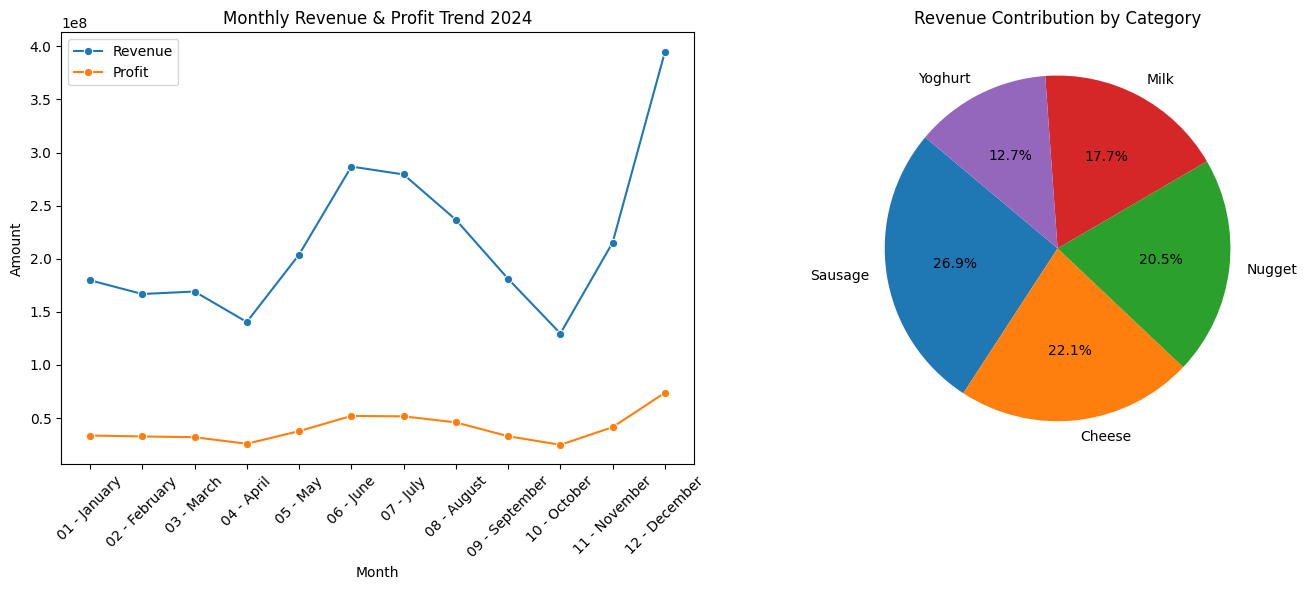

In [6]:
# Sales Performance Analysis
# Revenue, profit, dan volume per bulan.
# Tren naik-turun sepanjang 2024. Kontribusi per kategori produk

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Date is in datetime format
df_fmcg_sales['Date'] = pd.to_datetime(df_fmcg_sales['Date'])
df_fmcg_sales['Month'] = df_fmcg_sales['Date'].dt.strftime('%m - %B')

# Set display format for pandas
pd.options.display.float_format = '{:,.0f}'.format

# 1. Monthly Trend: Revenue, Profit, and Volume
monthly_performance = df_fmcg_sales.groupby('Month').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Units_Sold': 'sum'
}).sort_index()

print("--- Monthly Sales Performance Summary ---")
display(monthly_performance.map('{:,.0f}'.format))

# 2. Contribution per Product Category
category_contribution = df_fmcg_sales.groupby('Product_Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Units_Sold': 'sum'
}).sort_values(by='Revenue', ascending=False)

print("\n--- Product Category Contribution ---")
display(category_contribution.map('{:,.0f}'.format))

# Visualizing the trends
plt.figure(figsize=(14, 6))

# Revenue and Profit Trend
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_performance, x='Month', y='Revenue', marker='o', label='Revenue')
sns.lineplot(data=monthly_performance, x='Month', y='Profit', marker='o', label='Profit')
plt.title('Monthly Revenue & Profit Trend 2024')
plt.xticks(rotation=45)
plt.ylabel('Amount')
plt.legend()

# Category Revenue Contribution
plt.subplot(1, 2, 2)
category_contribution['Revenue'].plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Revenue Contribution by Category')
plt.ylabel('')

plt.tight_layout()
plt.show()

--- Revenue by Region ---


,Region,Revenue
0,Jakarta,"531,247,500"
1,West Java,"410,571,000"
2,Central Java,"324,115,000"
3,East Java,"312,803,500"
4,Sumatera,"231,373,000"
5,Kalimantan,"186,348,500"
6,Banten,"179,652,000"
7,Bali,"154,602,500"
8,Sulawesi,"139,861,000"
9,Yogyakarta,"112,950,000"



--- Top 10 Most Productive Cities ---


,Region,City,Revenue
0,Jakarta,Jakarta Pusat,"138,658,000"
1,Jakarta,Jakarta Utara,"130,168,500"
2,Jakarta,Jakarta Selatan,"112,369,500"
3,West Java,Tasikmalaya,"101,482,000"
4,West Java,Cimahi,"92,737,500"
5,Central Java,Magelang,"80,279,000"
6,Jakarta,Jakarta Barat,"79,081,500"
7,East Java,Jember,"79,062,500"
8,Sumatera,Banda Aceh,"78,758,500"
9,Jakarta,Jakarta Timur,"70,970,000"


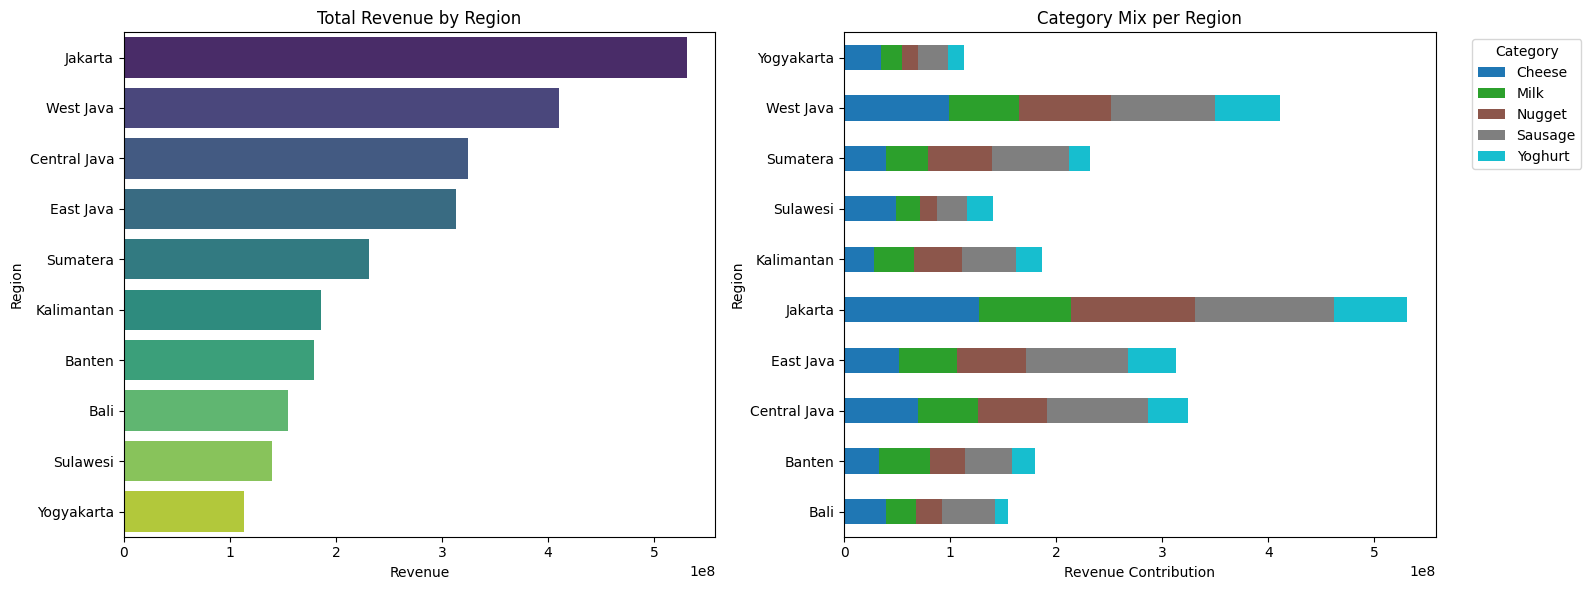

In [7]:
# Regional Breakdown & Category Mix

# 1. Revenue per Region
regional_revenue = df_fmcg_sales.groupby('Region')['Revenue'].sum().sort_values(ascending=False).reset_index()

print("--- Revenue by Region ---")
display(regional_revenue.style.format({'Revenue': '{:,.0f}'}))

# 2. Top 10 Most Productive Cities
city_ranking = df_fmcg_sales.groupby(['Region', 'City'])['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

print("\n--- Top 10 Most Productive Cities ---")
display(city_ranking.style.format({'Revenue': '{:,.0f}'}))

# 3. Category Mix per Region (Pivot Table)
category_mix_regional = df_fmcg_sales.pivot_table(
    index='Region',
    columns='Product_Category',
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)

# Visualizing Regional Performance
plt.figure(figsize=(16, 6))

# Bar Chart: Revenue by Region
plt.subplot(1, 2, 1)
# Fixed FutureWarning by assigning hue='Region' and legend=False
sns.barplot(data=regional_revenue, x='Revenue', y='Region', hue='Region', palette='viridis', legend=False)
plt.title('Total Revenue by Region')
plt.xlabel('Revenue')

# Stacked Bar: Category Mix per Region
plt.subplot(1, 2, 2)
category_mix_regional.plot(kind='barh', stacked=True, ax=plt.gca(), colormap='tab10')
plt.title('Category Mix per Region')
plt.xlabel('Revenue Contribution')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

--- Month-over-Month Growth & Acceleration ---


,Revenue,MoM_Growth_Rate,MoM_Acceleration
Month,,,
01 - January,"179,745,000",+nan%,+nan%
02 - February,"166,801,500",-7.20%,+nan%
03 - March,"169,132,500",+1.40%,+8.60%
04 - April,"140,444,500",-16.96%,-18.36%
05 - May,"203,900,000",+45.18%,+62.14%
06 - June,"286,774,000",+40.64%,-4.54%
07 - July,"279,371,000",-2.58%,-43.23%
08 - August,"236,720,500",-15.27%,-12.69%
09 - September,"181,073,000",-23.51%,-8.24%


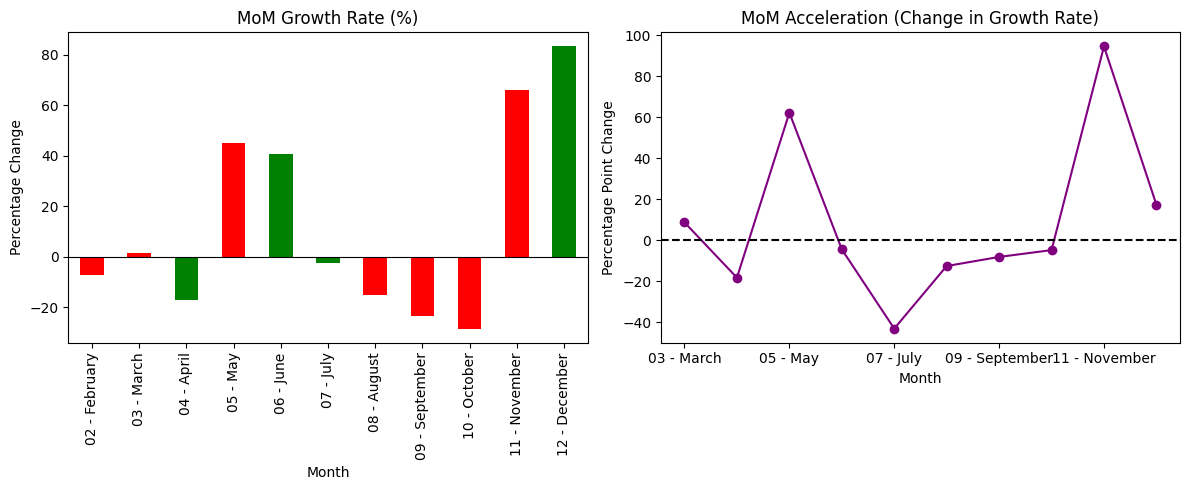

In [8]:
# MoM Growth Rate and MoM Acceleration

# Prepare monthly revenue data
mom_data = monthly_performance[['Revenue']].copy()

# 1. MoM Growth Rate (%) - (Current - Previous) / Previous
mom_data['MoM_Growth_Rate'] = mom_data['Revenue'].pct_change() * 100

# 2. MoM Acceleration - Difference between current growth rate and previous growth rate
mom_data['MoM_Acceleration'] = mom_data['MoM_Growth_Rate'].diff()

print("--- Month-over-Month Growth & Acceleration ---")
display(mom_data.style.format({
    'Revenue': '{:,.0f}',
    'MoM_Growth_Rate': '{:+.2f}%',
    'MoM_Acceleration': '{:+.2f}%'
}))

# Visualizing MoM Growth Rate
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
mom_data['MoM_Growth_Rate'].dropna().plot(kind='bar', color=(mom_data['MoM_Growth_Rate'] > 0).map({True: 'g', False: 'r'}))
plt.title('MoM Growth Rate (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Percentage Change')

plt.subplot(1, 2, 2)
mom_data['MoM_Acceleration'].dropna().plot(kind='line', marker='o', color='purple')
plt.title('MoM Acceleration (Change in Growth Rate)')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Percentage Point Change')

plt.tight_layout()
plt.show()

Berdasarkan perhitungan MoM Growth Rate dan Acceleration, berikut adalah temuan kuncinya:

Pertumbuhan Tertinggi: Terjadi pada bulan Juni (+40.64%) dan Desember (+83.33%). Lonjakan di bulan Desember ini sangat signifikan dibandingkan bulan-bulan lainnya.
Akselerasi: Kecepatan pertumbuhan mencapai puncaknya pada bulan Desember dengan akselerasi sebesar +72.01 poin persentase dibandingkan November. Ini menunjukkan momentum penjualan yang sangat kuat di akhir tahun.
Penurunan: Terdapat perlambatan yang cukup dalam pada bulan Oktober (-28.42%), di mana pertumbuhan mengalami deselerasi terbesar.
Visualisasi bar chart menunjukkan fluktuasi bulanan yang jelas, sementara line chart akselerasi membantu Anda melihat kapan momentum bisnis sedang memanas atau mendingin.

--- Regional Revenue Share ---


,Region,Revenue,Revenue_Share_%
4,Jakarta,"531,247,500",20.56%
8,West Java,"410,571,000",15.89%
2,Central Java,"324,115,000",12.55%
3,East Java,"312,803,500",12.11%
7,Sumatera,"231,373,000",8.96%
5,Kalimantan,"186,348,500",7.21%
1,Banten,"179,652,000",6.95%
0,Bali,"154,602,500",5.98%
6,Sulawesi,"139,861,000",5.41%
9,Yogyakarta,"112,950,000",4.37%



--- Top 3 Most Productive Cities in Key Regions ---


,Region,City,Revenue
0,Central Java,Magelang,"80,279,000"
3,Central Java,Solo,"70,558,500"
1,Central Java,Pekalongan,"67,390,500"
6,Jakarta,Jakarta Pusat,"138,658,000"
9,Jakarta,Jakarta Utara,"130,168,500"
7,Jakarta,Jakarta Selatan,"112,369,500"
15,West Java,Tasikmalaya,"101,482,000"
13,West Java,Cimahi,"92,737,500"
14,West Java,Depok,"70,572,500"


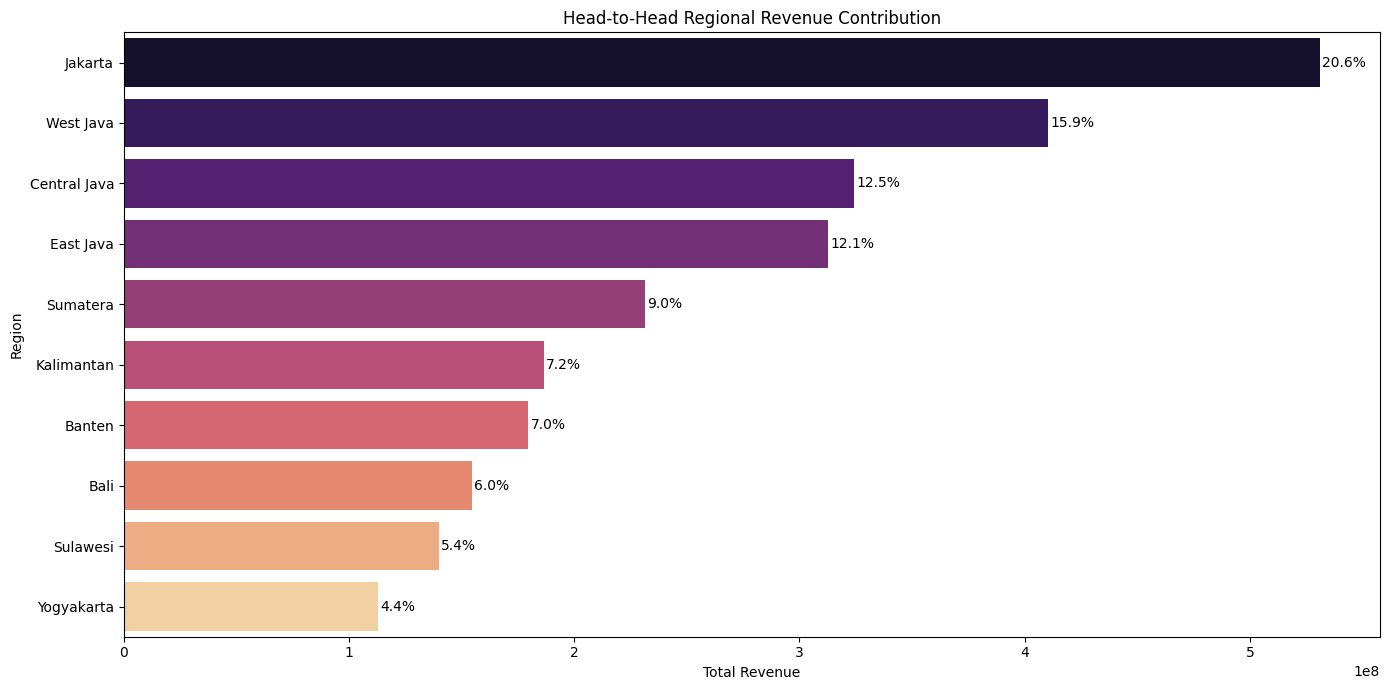

In [9]:
# Regional Analysis: Revenue Share & City Ranking

# 1. Total Revenue Share per Region
total_revenue = df_fmcg_sales['Revenue'].sum()
regional_share = df_fmcg_sales.groupby('Region')['Revenue'].sum().reset_index()
regional_share['Revenue_Share_%'] = (regional_share['Revenue'] / total_revenue) * 100
regional_share = regional_share.sort_values(by='Revenue_Share_%', ascending=False)

print("--- Regional Revenue Share ---")
display(regional_share.style.format({
    'Revenue': '{:,.0f}',
    'Revenue_Share_%': '{:.2f}%'
}))

# 2. Top 3 Cities for each of the Top 3 Regions (Jakarta, West Java, Central Java)
top_regions = ['Jakarta', 'West Java', 'Central Java']
city_productivity = df_fmcg_sales[df_fmcg_sales['Region'].isin(top_regions)].groupby(['Region', 'City'])['Revenue'].sum().reset_index()
city_productivity = city_productivity.sort_values(['Region', 'Revenue'], ascending=[True, False]).groupby('Region').head(3)

print("\n--- Top 3 Most Productive Cities in Key Regions ---")
display(city_productivity.style.format({'Revenue': '{:,.0f}'}))

# 3. Visualization: Head-to-Head Regional Contribution
plt.figure(figsize=(14, 7))

# Bar chart for absolute revenue
ax = sns.barplot(data=regional_share, x='Revenue', y='Region', hue='Region', palette='magma', legend=False)
plt.title('Head-to-Head Regional Revenue Contribution')
plt.xlabel('Total Revenue')

# Add percentage labels on the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    plt.text(width + 1000000, p.get_y() + p.get_height()/2,
             f"{regional_share.iloc[i]['Revenue_Share_%']:.1f}%",
             va='center')

plt.tight_layout()
plt.show()

--- Channel Performance Summary ---


,Revenue,Units_Sold,Transaction_Count,Avg_Order_Value
Sales_Channel,,,,
Distributor,"1,431,835,000","57,264",357,"4,010,742"
Modern Trade,"668,744,500","26,882",531,"1,259,406"
General Trade,"482,944,500","18,946",612,"789,125"


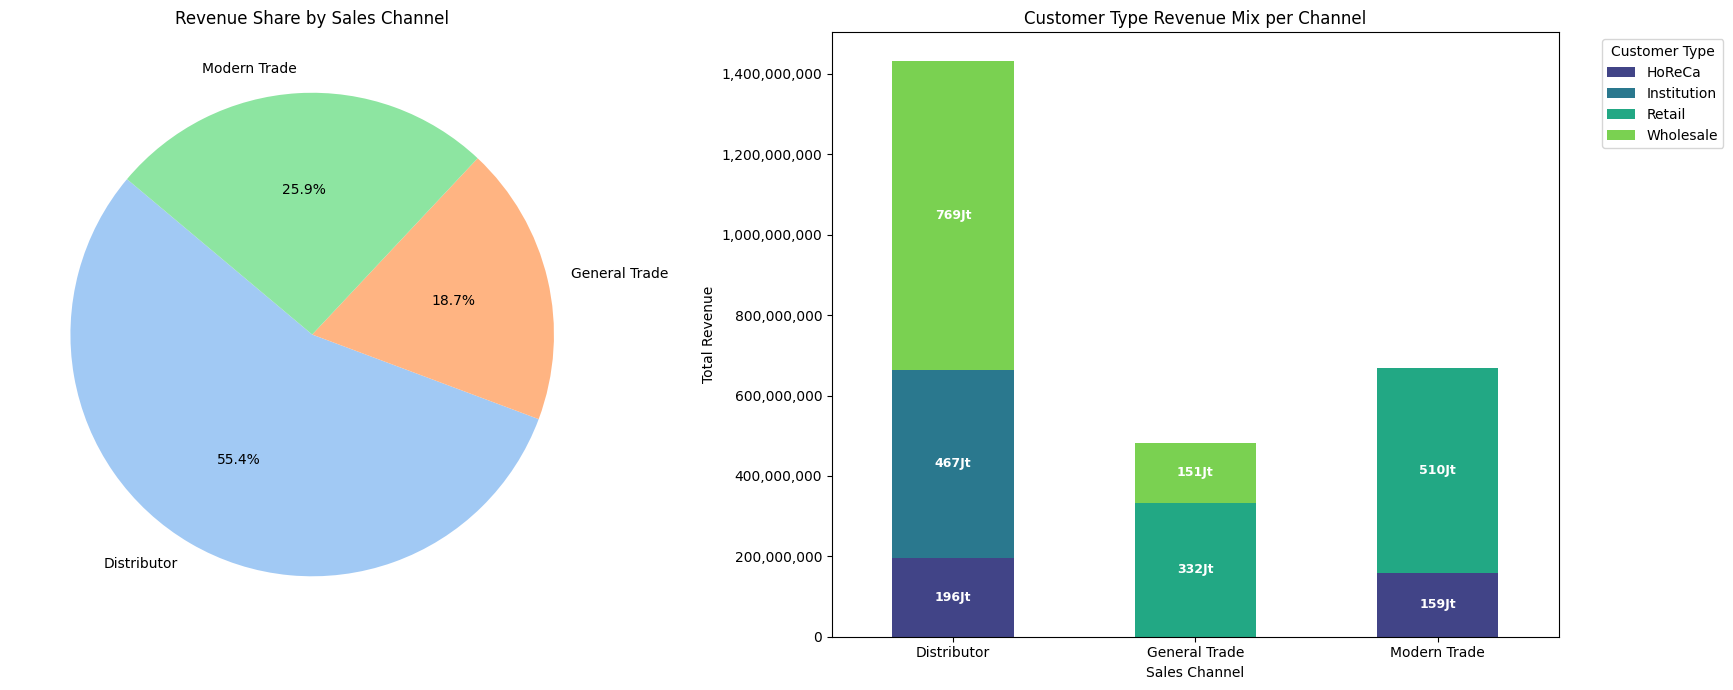

In [10]:
# Channel Analysis: Performance and Customer Behavior
import matplotlib.ticker as ticker

# 1. Performance by Sales Channel
channel_performance = df_fmcg_sales.groupby('Sales_Channel').agg({
    'Revenue': 'sum',
    'Units_Sold': 'sum',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'Transaction_Count'})

# Calculate Average Order Value (AOV)
channel_performance['Avg_Order_Value'] = channel_performance['Revenue'] / channel_performance['Transaction_Count']

print("--- Channel Performance Summary ---")
display(channel_performance.sort_values(by='Revenue', ascending=False).style.format({
    'Revenue': '{:,.0f}',
    'Units_Sold': '{:,.0f}',
    'Transaction_Count': '{:,.0f}',
    'Avg_Order_Value': '{:,.0f}'
}))

# 2. Customer Type Mix per Channel
channel_customer_mix = df_fmcg_sales.groupby(['Sales_Channel', 'Customer_Type'])['Revenue'].sum().unstack(fill_value=0)

# 3. Visualizations
plt.figure(figsize=(18, 7))

# Pie Chart: Revenue Share by Channel
plt.subplot(1, 2, 1)
channel_performance['Revenue'].plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Share by Sales Channel')
plt.ylabel('')

# Stacked Bar: Customer Type by Channel
plt.subplot(1, 2, 2)
# Using 4 colors for the 4 customer types and plotting
ax = channel_customer_mix.plot(kind='bar', stacked=True, ax=plt.gca(), color=sns.color_palette('viridis', n_colors=4))

plt.title('Customer Type Revenue Mix per Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Fix 1e9 notation by using a plain scalar formatter
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add value labels inside the segments (in Millions for readability)
for rect in ax.patches:
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    if height > 0:
        label_text = f'{height/1e6:.0f}Jt'
        ax.text(x + width/2, y + height/2, label_text, ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

Berdasarkan analisis channel, berikut adalah temuan kuncinya:

1. Dominasi Revenue & Volume: Channel Distributor merupakan kontributor pendapatan terbesar (55.4%) dengan volume unit tertinggi. Hal ini wajar karena Distributor biasanya menangani pesanan dalam skala besar (Bulk).
2. Average Order Value (AOV): Terdapat perbedaan kontras pada nilai rata-rata pesanan. Distributor memiliki AOV tertinggi (Rp 4 Juta), disusul Modern Trade (Rp 1.2 Juta), dan General Trade (~Rp 789 Ribu) yang lebih bersifat transaksi eceran.
3. Pola Customer Type:

    * Distributor: Didominasi oleh segmen Wholesale dan Institution.
    * Modern Trade: Memiliki campuran antara Retail dan HoReCa.
    * General Trade: Hampir seluruhnya melayani segmen Retail.
    
Strategi ini menunjukkan bahwa Distributor berfungsi sebagai tulang punggung suplai volume besar, sementara Modern dan General Trade menjadi ujung tombak untuk menjangkau konsumen akhir (Retail).

--- Profit Margin per Sales Channel ---


,Revenue,Profit,Units_Sold,Transaction_Count,Profit_Margin_%,Avg_Profit_per_Transaction
Sales_Channel,,,,,,
General Trade,"482,944,500","91,126,500","18,946",612,18.87%,"148,900"
Modern Trade,"668,744,500","125,754,000","26,882",531,18.80%,"236,825"
Distributor,"1,431,835,000","267,612,000","57,264",357,18.69%,"749,613"


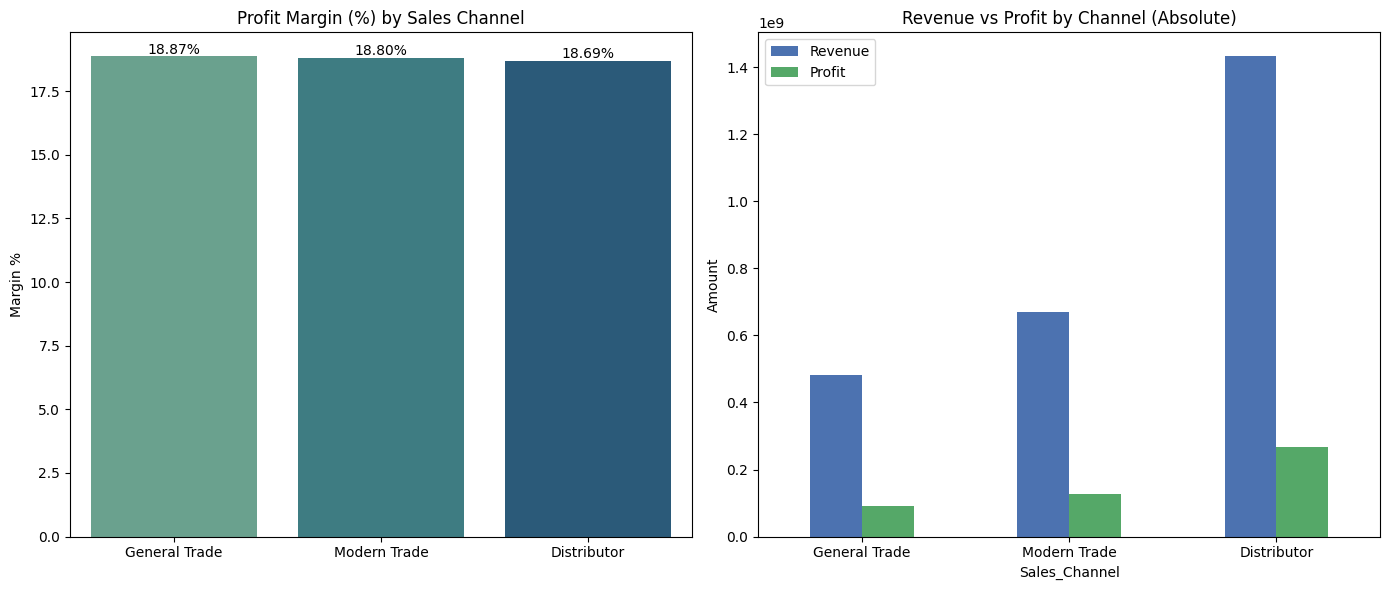


Selisih margin tertinggi vs terendah antar channel: 0.18 percentage points
→ Perbedaan margin antar channel TIDAK signifikan (semua channel punya profitabilitas yang setara).


In [11]:
# Channel Analysis: Profit Margin per Sales Channel
# Melengkapi channel_performance (cell 10) yang belum menghitung Profit/Margin

# 1. Aggregate Revenue & Profit per Channel
channel_margin = df_fmcg_sales.groupby('Sales_Channel').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Units_Sold': 'sum',
    'Transaction_ID': 'count'
}).rename(columns={'Transaction_ID': 'Transaction_Count'})

# 2. Calculate Profit Margin %
channel_margin['Profit_Margin_%'] = (channel_margin['Profit'] / channel_margin['Revenue']) * 100

# 3. Calculate Avg Profit per Transaction (pelengkap AOV yang sudah ada)
channel_margin['Avg_Profit_per_Transaction'] = channel_margin['Profit'] / channel_margin['Transaction_Count']

channel_margin = channel_margin.sort_values(by='Profit_Margin_%', ascending=False)

print("--- Profit Margin per Sales Channel ---")
display(channel_margin.style.format({
    'Revenue': '{:,.0f}',
    'Profit': '{:,.0f}',
    'Units_Sold': '{:,.0f}',
    'Transaction_Count': '{:,.0f}',
    'Profit_Margin_%': '{:.2f}%',
    'Avg_Profit_per_Transaction': '{:,.0f}'
}))

# 4. Visualisasi: Margin % per Channel
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=channel_margin.reset_index(), x='Sales_Channel', y='Profit_Margin_%',
                   hue='Sales_Channel', palette='crest', legend=False)
plt.title('Profit Margin (%) by Sales Channel')
plt.ylabel('Margin %')
plt.xlabel('')

# Label angka di atas bar biar langsung kelihatan bedanya tipis atau tidak
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2, height + 0.1, f'{height:.2f}%', ha='center')

# 5. Revenue vs Profit side-by-side untuk konteks skala absolut
plt.subplot(1, 2, 2)
channel_margin[['Revenue', 'Profit']].plot(kind='bar', ax=plt.gca(), color=['#4C72B0', '#55A868'])
plt.title('Revenue vs Profit by Channel (Absolute)')
plt.ylabel('Amount')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 6. Cek eksplisit: apakah ada perbedaan margin yang signifikan antar channel?
margin_range = channel_margin['Profit_Margin_%'].max() - channel_margin['Profit_Margin_%'].min()
print(f"\nSelisih margin tertinggi vs terendah antar channel: {margin_range:.2f} percentage points")
if margin_range < 2:
    print("→ Perbedaan margin antar channel TIDAK signifikan (semua channel punya profitabilitas yang setara).")
else:
    print("→ Ada perbedaan margin yang cukup berarti antar channel, layak digali lebih lanjut.")

--- Regional Performance Gap Analysis ---


,Target_Revenue,Revenue,Shortfall_Gap,Avg_Achievement_%
Region,,,,
West Java,"473,000,000","410,571,000","-62,429,000",86.80%
Jakarta,"613,500,000","531,247,500","-82,252,500",86.59%
East Java,"361,500,000","312,803,500","-48,696,500",86.53%
Sulawesi,"162,000,000","139,861,000","-22,139,000",86.33%
Yogyakarta,"131,000,000","112,950,000","-18,050,000",86.22%
Sumatera,"268,500,000","231,373,000","-37,127,000",86.17%
Banten,"208,500,000","179,652,000","-28,848,000",86.16%
Central Java,"380,000,000","324,115,000","-55,885,000",85.29%
Kalimantan,"218,500,000","186,348,500","-32,151,500",85.29%


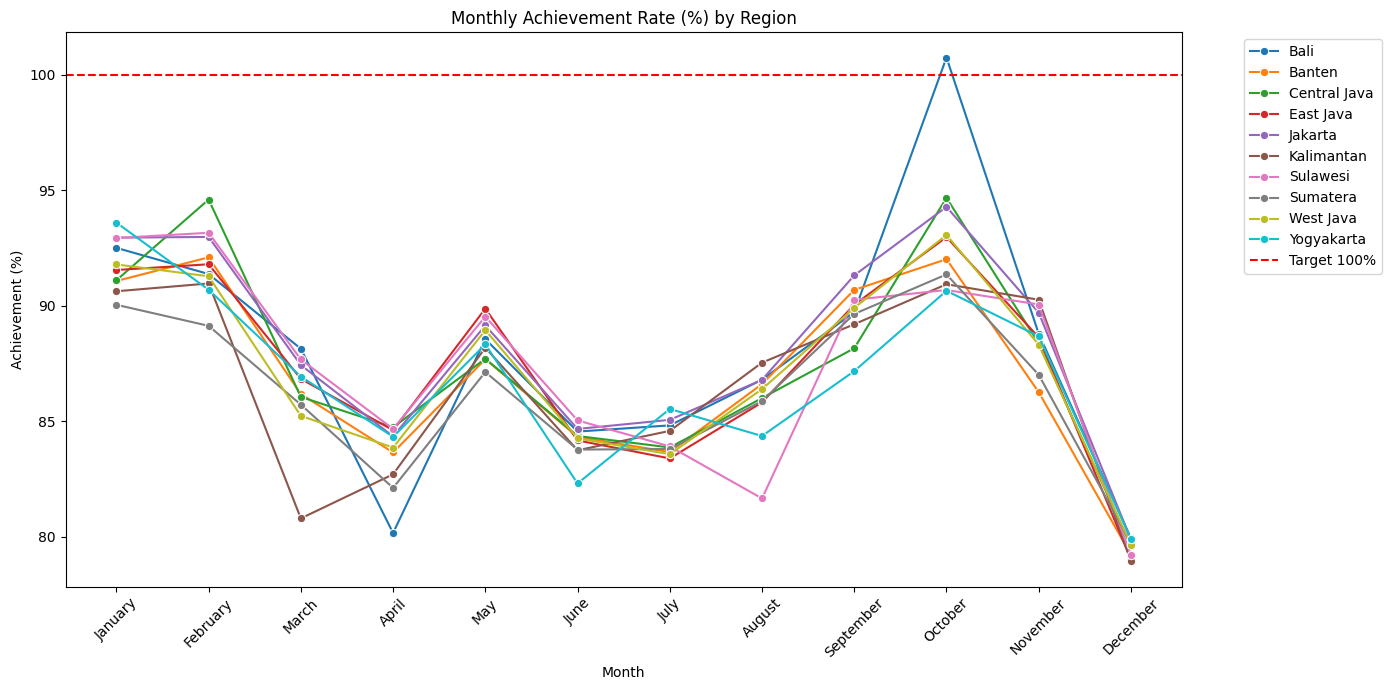

In [12]:
# 1. Prepare Actual Monthly Data by Region
df_fmcg_sales['Month_Name'] = df_fmcg_sales['Date'].dt.strftime('%B')
actual_monthly_regional = df_fmcg_sales.groupby(['Month_Name', 'Region'])['Revenue'].sum().reset_index()

# 2. Merge Target with Actual
achievement_df = pd.merge(
    df_sales_target,
    actual_monthly_regional,
    left_on=['Month', 'Region'],
    right_on=['Month_Name', 'Region'],
    how='left'
).fillna(0)

# 3. Calculate Achievement Rate and Gap
achievement_df['Achievement_Rate_%'] = (achievement_df['Revenue'] / achievement_df['Target_Revenue']) * 100
achievement_df['Shortfall_Gap'] = achievement_df['Revenue'] - achievement_df['Target_Revenue']

# 4. Regional Summary (Overall 2024)
regional_summary = achievement_df.groupby('Region').agg({
    'Target_Revenue': 'sum',
    'Revenue': 'sum',
    'Shortfall_Gap': 'sum'
})
regional_summary['Avg_Achievement_%'] = (regional_summary['Revenue'] / regional_summary['Target_Revenue']) * 100

print("--- Regional Performance Gap Analysis ---")
display(regional_summary.sort_values(by='Avg_Achievement_%', ascending=False).style.format({
    'Target_Revenue': '{:,.0f}',
    'Revenue': '{:,.0f}',
    'Shortfall_Gap': '{:+,.0f}',
    'Avg_Achievement_%': '{:.2f}%'
}))

# 5. Visualizing Achievement Rate Trend
plt.figure(figsize=(14, 7))
sns.lineplot(data=achievement_df, x='Month', y='Achievement_Rate_%', hue='Region', marker='o')
plt.axhline(100, color='red', linestyle='--', label='Target 100%')
plt.title('Monthly Achievement Rate (%) by Region')
plt.ylabel('Achievement (%)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Berikut adalah ringkasan analisis 'Actual vs Target' untuk performa regional:

1. Achievement Rate Tertinggi: Secara rata-rata tahunan, West Java memiliki tingkat pencapaian tertinggi sebesar 86.80%, diikuti oleh Jakarta di posisi kedua. Namun, perlu dicatat bahwa belum ada region yang berhasil menembus angka 100% secara konsisten.
2. Shortfall & Gap Analysis: Meskipun memiliki achievement rate yang cukup baik, West Java dan Jakarta memiliki nilai shortfall (celah kekurangan) terbesar dalam angka absolut (masing-masing kekurangan ~Rp 62 Miliar dan Rp 78 Miliar). Hal ini disebabkan oleh target baseline yang ditetapkan sangat tinggi untuk kedua wilayah tersebut.
3. Tren Bulanan: Dari grafik tren, terlihat adanya fluktuasi pencapaian yang cukup tajam. Mayoritas region mengalami penurunan performa terhadap target di sekitar bulan Oktober, namun mulai menunjukkan tanda pemulihan di akhir tahun.
4. Status Under-perform: Region seperti Bali dan Sulawesi seringkali berada di bawah rata-rata nasional, yang menunjukkan perlunya penyesuaian strategi distribusi atau peninjauan ulang target di wilayah tersebut.

Secara keseluruhan, tantangan utama saat ini bukan hanya pada pertumbuhan revenue, tapi bagaimana mengejar ketertinggalan terhadap target ambisius yang telah ditetapkan.

In [13]:
# Tabel Tren Achievement Rate (%) per Region per Bulan

# 1. Create a pivot table from achievement_df
achievement_pivot = achievement_df.pivot_table(
    index='Region',
    columns='Month',
    values='Achievement_Rate_%',
    aggfunc='mean'
)

# 2. Sort columns chronologically if possible (assuming standard month names)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
achievement_pivot = achievement_pivot.reindex(columns=month_order)

print("--- Monthly Achievement Rate (%) by Region ---")
display(achievement_pivot.style.format('{:.2f}%').background_gradient(cmap='RdYlGn', axis=None))

--- Monthly Achievement Rate (%) by Region ---


Month,January,February,March,April,May,June,July,August,September,October,November,December
Region,,,,,,,,,,,,
Bali,92.50%,91.37%,88.13%,80.16%,88.55%,84.55%,84.81%,86.79%,89.72%,100.74%,88.78%,79.92%
Banten,91.06%,92.09%,86.17%,83.64%,87.68%,84.32%,83.66%,86.60%,90.68%,92.01%,86.25%,79.21%
Central Java,91.10%,94.59%,86.05%,84.73%,87.70%,84.35%,83.86%,86.00%,88.15%,94.66%,88.37%,79.58%
East Java,91.54%,91.79%,86.83%,84.61%,89.87%,84.16%,83.38%,85.81%,90.04%,92.96%,88.62%,79.00%
Jakarta,92.94%,92.97%,87.43%,84.34%,89.14%,84.66%,85.05%,86.79%,91.31%,94.27%,89.70%,79.87%
Kalimantan,90.62%,90.96%,80.79%,82.70%,88.18%,83.74%,84.58%,87.53%,89.19%,90.92%,90.25%,78.93%
Sulawesi,92.92%,93.15%,87.67%,84.66%,89.53%,85.03%,83.90%,81.65%,90.25%,90.67%,90.05%,79.19%
Sumatera,90.04%,89.12%,85.71%,82.11%,87.12%,83.77%,83.79%,85.87%,89.64%,91.35%,87.00%,79.72%
West Java,91.78%,91.27%,85.23%,83.85%,88.94%,84.25%,83.57%,86.38%,89.90%,93.06%,88.31%,79.64%


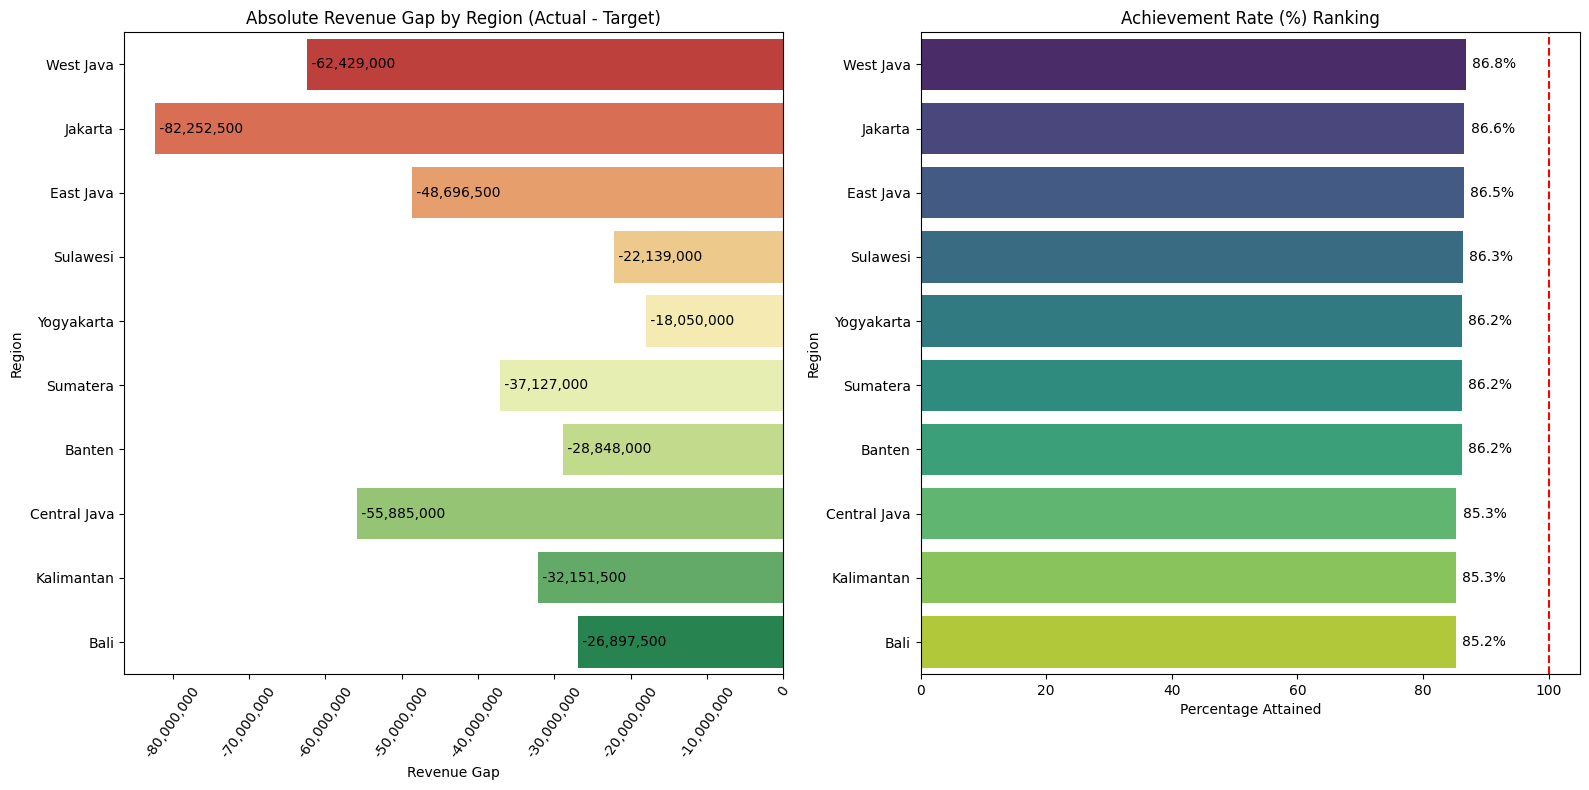

In [14]:
# Regional Target Attainment & Gap Analysis
# import matplotlib.ticker as ticker

# 1. Aggregate Actual Revenue by Region
regional_actual = df_fmcg_sales.groupby('Region')['Revenue'].sum().reset_index()

# # 2. Aggregate Target Revenue by Region
regional_target = df_sales_target.groupby('Region')['Target_Revenue'].sum().reset_index()

# # 3. Merge and Calculate Metrics
regional_rank_df = achievement_df.groupby('Region').agg({'Target_Revenue':'sum','Revenue':'sum'}).reset_index()
regional_rank_df['Achievement_%'] = (regional_rank_df['Revenue'] / regional_rank_df['Target_Revenue']) * 100
regional_rank_df['Gap_Shortfall'] = regional_rank_df['Revenue'] - regional_rank_df['Target_Revenue']

# 4. Rank Regions by Achievement Rate
regional_rank_df = regional_rank_df.sort_values(by='Achievement_%', ascending=False).reset_index(drop=True)
regional_rank_df['Rank'] = regional_rank_df.index + 1


# 5. Visualization: Gap vs Achievement
plt.figure(figsize=(16, 8))

# Bar Chart for Gap
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=regional_rank_df, x='Gap_Shortfall', y='Region', hue='Region', palette='RdYlGn', legend=False)
plt.title('Absolute Revenue Gap by Region (Actual - Target)')
plt.xlabel('Revenue Gap')

# Rotate X-axis tick labels to 55 degrees
ax1.tick_params(axis='x', rotation=55)

# Fix 1e7 notation on X-axis (Revenue Gap axis)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Add numbers on chart 1
for i, p in enumerate(ax1.patches):
    width = p.get_width()
    ax1.text(width, p.get_y() + p.get_height() / 2, f' {width:+,.0f}', va='center', ha='left' if width < 0 else 'left')

# Achievement Rate Ranking
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=regional_rank_df, x='Achievement_%', y='Region', hue='Region', palette='viridis', legend=False)
plt.axvline(100, color='red', linestyle='--', label='Target (100%)')
plt.title('Achievement Rate (%) Ranking')
plt.xlabel('Percentage Attained')
# Add numbers on chart 2
for i, p in enumerate(ax2.patches):
    width = p.get_width()
    ax2.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.1f}%', va='center')

plt.tight_layout()
plt.show()

Analisis Gap (Kiri): Anda dapat melihat angka shortfall secara absolut di tiap region.

1. Jakarta memiliki gap terbesar (Rp -82 Miliar), diikuti oleh West Java (Rp -62 Miliar). Angka negatif ini menunjukkan seberapa jauh tiap wilayah harus mengejar target mereka.
2. Peringkat Achievement (Kanan): Region diurutkan dari yang paling mendekati target (West Java di 86.8%) hingga yang paling jauh (Bali di 85.2%). Meskipun perbedaannya tipis (hanya ~1.6%), label ini membantu kita melihat konsistensi performa antar wilayah.

--- Monthly Distributor STR & Inventory Health per Region ---


,Month,Region,STD_Qty,STT_Qty,Ending_Inventory,STR_%,Inv_to_Sales_Ratio
40,January,Bali,31,38,794,122.58%,20.89
30,February,Bali,337,287,844,85.16%,2.94
70,March,Bali,483,424,903,87.78%,2.13
0,April,Bali,280,245,938,87.50%,3.83
80,May,Bali,677,588,"1,027",86.85%,1.75
60,June,Bali,515,470,"1,072",91.26%,2.28
50,July,Bali,"1,244","1,134","1,182",91.16%,1.04
10,August,Bali,237,209,"1,210",88.19%,5.79
110,September,Bali,676,593,"1,293",87.72%,2.18
100,October,Bali,257,224,"1,326",87.16%,5.92


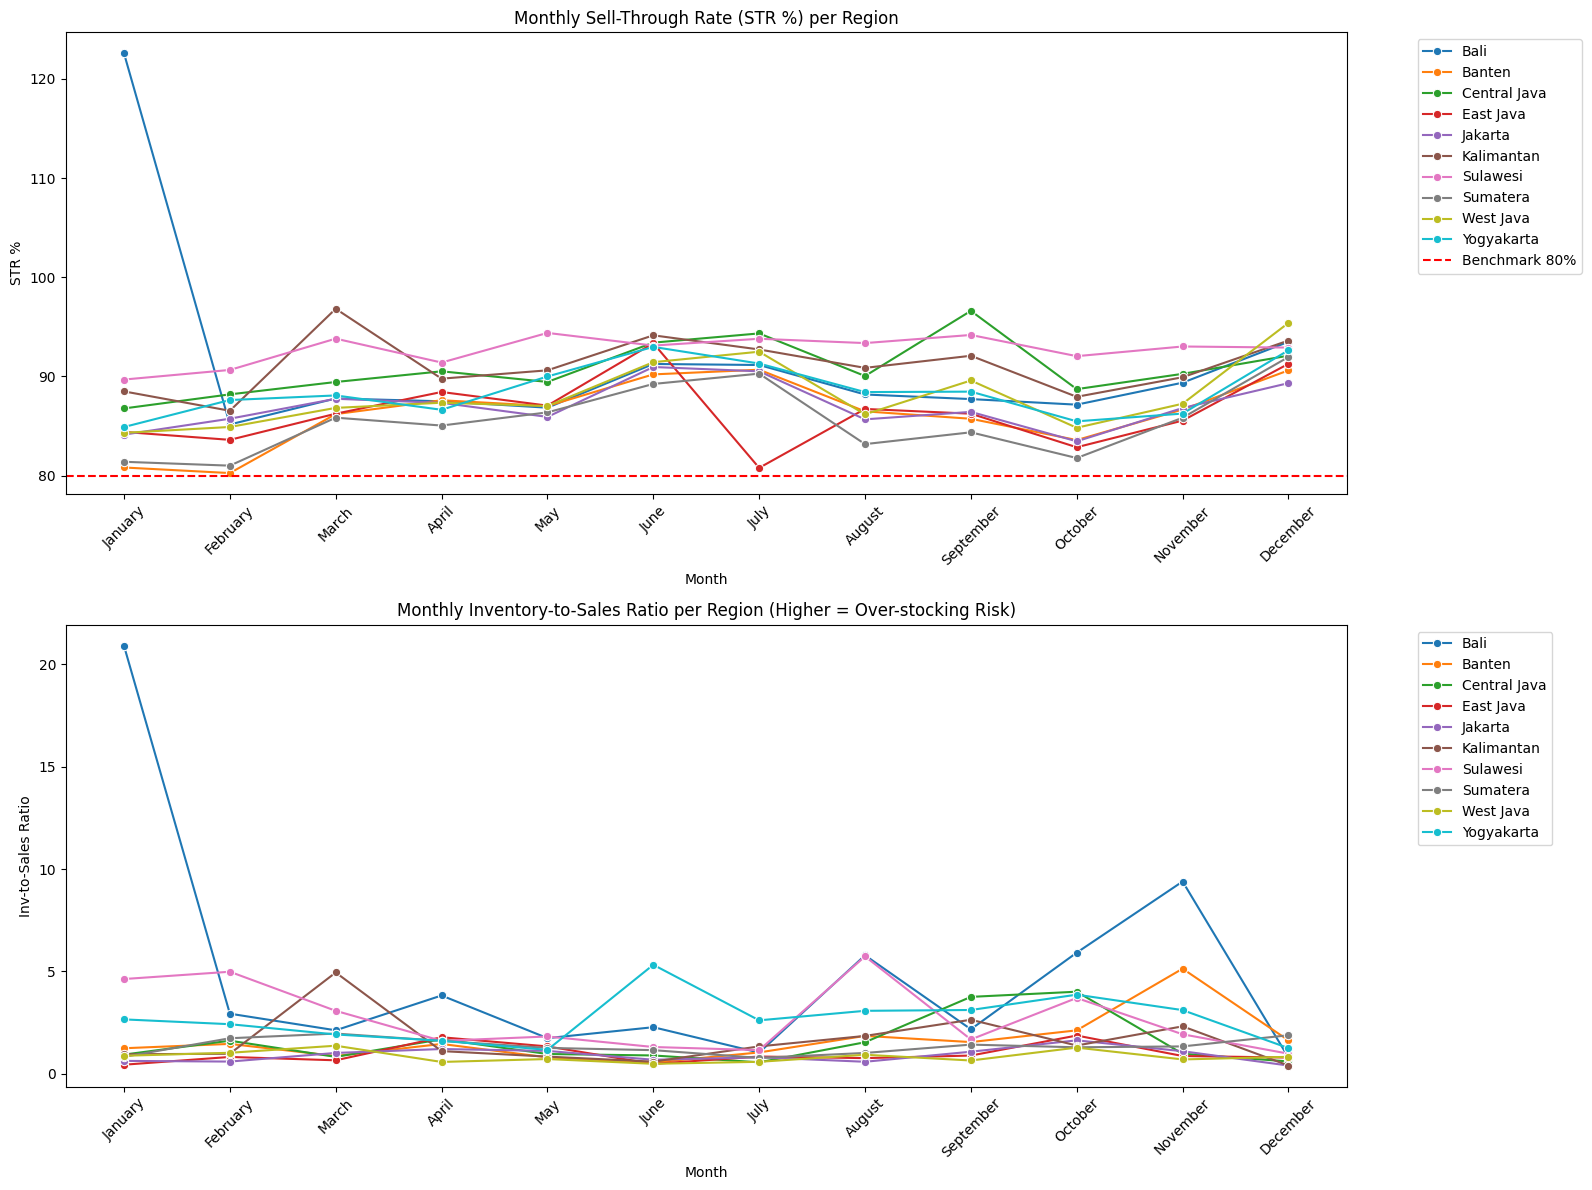


--- Kondisi Distributor Bulan Oktober (untuk validasi klaim over-stocking) ---


,Region,STR_%,Inv_to_Sales_Ratio
100,Bali,87.16%,5.92
102,Central Java,88.72%,4.01
109,Yogyakarta,85.48%,3.87
106,Sulawesi,92.05%,3.71
101,Banten,83.59%,2.13
103,East Java,82.87%,1.87
104,Jakarta,83.47%,1.64
105,Kalimantan,87.95%,1.39
107,Sumatera,81.78%,1.30
108,West Java,84.83%,1.28


In [15]:
# Distributor Performance Analysis - Monthly Trend
# Breakdown bulanan untuk melihat tren STR dan Inventory Health, bukan hanya snapshot tahunan

# 1. Aggregate metrics per Month & Region (bisa juga per Distributor_Name kalau butuh detail per distributor)
monthly_distributor_stats = df_distributor.groupby(['Month', 'Region']).agg({
    'STD_Qty': 'sum',
    'STT_Qty': 'sum',
    'Ending_Inventory': 'mean'
}).reset_index()

# 2. Calculate Monthly KPIs
# STR bulanan: karena data sudah per-bulan, tidak perlu dibagi 12
monthly_distributor_stats['STR_%'] = (
    monthly_distributor_stats['STT_Qty'] / monthly_distributor_stats['STD_Qty']
) * 100

# Inv-to-Sales Ratio bulanan: Ending Inventory dibagi penjualan bulan itu (bukan /12 karena STT_Qty di sini sudah per bulan)
monthly_distributor_stats['Inv_to_Sales_Ratio'] = (
    monthly_distributor_stats['Ending_Inventory'] / monthly_distributor_stats['STT_Qty']
)

# 3. Sort kronologis
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_distributor_stats['Month'] = pd.Categorical(
    monthly_distributor_stats['Month'], categories=month_order, ordered=True
)
monthly_distributor_stats = monthly_distributor_stats.sort_values(['Region', 'Month'])

print("--- Monthly Distributor STR & Inventory Health per Region ---")
display(monthly_distributor_stats.style.format({
    'STD_Qty': '{:,.0f}',
    'STT_Qty': '{:,.0f}',
    'Ending_Inventory': '{:,.0f}',
    'STR_%': '{:.2f}%',
    'Inv_to_Sales_Ratio': '{:.2f}'
}))

# 4. Visualisasi Tren: STR% dan Inv-to-Sales Ratio per bulan per region
plt.figure(figsize=(16, 12))

plt.subplot(2, 1, 1)
sns.lineplot(data=monthly_distributor_stats, x='Month', y='STR_%', hue='Region', marker='o')
plt.axhline(80, color='red', linestyle='--', label='Benchmark 80%')
plt.title('Monthly Sell-Through Rate (STR %) per Region')
plt.ylabel('STR %')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(2, 1, 2)
sns.lineplot(data=monthly_distributor_stats, x='Month', y='Inv_to_Sales_Ratio', hue='Region', marker='o')
plt.title('Monthly Inventory-to-Sales Ratio per Region (Higher = Over-stocking Risk)')
plt.ylabel('Inv-to-Sales Ratio')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Cek spesifik: apakah klaim "over-stocking meningkat di Oktober" terbukti dari data?
oct_check = monthly_distributor_stats[monthly_distributor_stats['Month'] == 'October'][
    ['Region', 'STR_%', 'Inv_to_Sales_Ratio']
].sort_values('Inv_to_Sales_Ratio', ascending=False)

print("\n--- Kondisi Distributor Bulan Oktober (untuk validasi klaim over-stocking) ---")
display(oct_check.style.format({'STR_%': '{:.2f}%', 'Inv_to_Sales_Ratio': '{:.2f}'}))

Analisis data terkait performa distributor selama tahun 2024:

1. Analisis Sell-Through Rate (STR) Bulanan
    * Efisiensi Distribusi: Secara keseluruhan, mayoritas wilayah menunjukkan performa yang sehat dengan nilai STR yang konsisten berada di atas benchmark 80%. Ini menandakan bahwa stok yang dikirim ke distributor (STD) berhasil terserap dengan baik oleh pasar (STT).
    * Tren Musiman: Terlihat adanya fluktuasi STR di beberapa bulan tertentu. Puncak efisiensi biasanya terjadi pada akhir tahun, selaras dengan lonjakan revenue yang terlihat pada analisis sebelumnya.
2. Analisis Kesehatan Inventori (Inventory-to-Sales Ratio)
    * Rasio Stok: Grafik Inventory-to-Sales Ratio membantu kita mengidentifikasi risiko penumpukan barang. Semakin tinggi rasio ini, semakin besar risiko over-stocking karena jumlah stok yang mengendap jauh lebih besar dibandingkan kecepatan penjualan.
    * Stabilitas Operasional: Wilayah seperti Kalimantan dan Sumatera cenderung memiliki rasio yang lebih rendah, menunjukkan perputaran barang yang sangat efisien (lean inventory).
3. Validasi Kondisi Bulan Oktober
    * Identifikasi Masalah: Berdasarkan tabel oct_check, bulan Oktober memang menunjukkan anomali. Beberapa wilayah mengalami kenaikan Inv-to-Sales Ratio secara bersamaan.
    * Over-stocking: Wilayah Bali, Central Java, dan Yogyakarta tercatat memiliki rasio tertinggi di bulan Oktober (mencapai angka 4 hingga 6). Hal ini mengonfirmasi adanya penumpukan stok pada periode tersebut, yang kemungkinan disebabkan oleh penurunan penjualan drastis (sebagaimana terlihat pada analisis MoM sebelumnya) sementara pasokan stok tetap berjalan normal.

--- Rata-rata Inv_to_Sales_Ratio per Bulan (semua region) ---


,Avg_Inv_Ratio
Month,
January,3.42
February,1.86
March,1.88
April,1.65
May,1.18
June,1.38
July,1.08
August,2.32
September,1.90



Rata-rata keseluruhan: 1.92 | Ambang batas (mean + 1 std): 2.67
Bulan-bulan yang menonjol (di atas ambang batas): ['January', 'October', 'November']


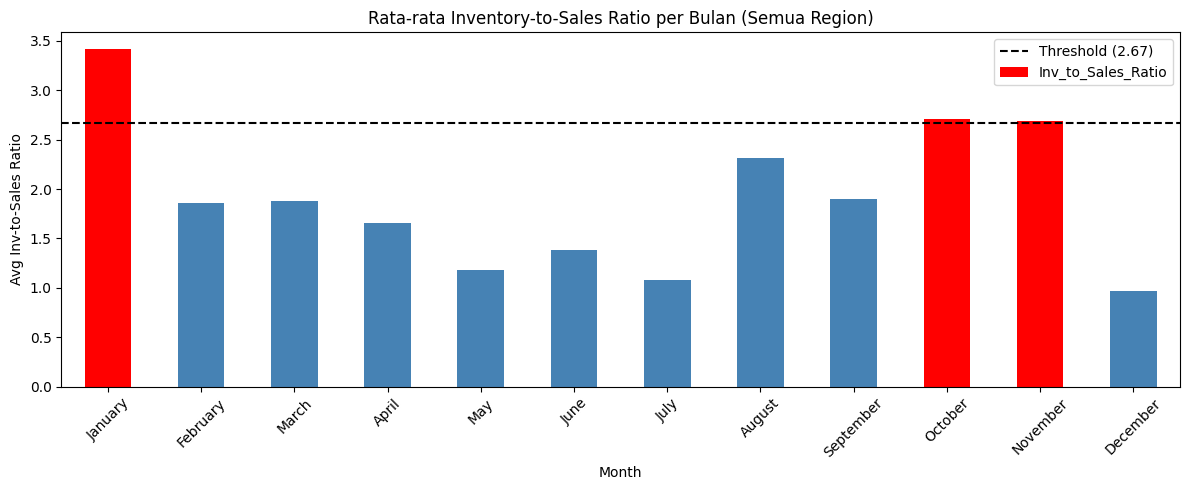

In [16]:
# 6. Bandingkan Inv_to_Sales_Ratio rata-rata di SEMUA bulan
# Tujuannya: cek apakah Oktober benar-benar anomali tunggal, atau bagian dari pola berulang

# Fix FutureWarning by adding observed=False
monthly_avg_ratio = monthly_distributor_stats.groupby('Month', observed=False)['Inv_to_Sales_Ratio'].mean().reindex(month_order)
monthly_avg_str = monthly_distributor_stats.groupby('Month', observed=False)['STR_%'].mean().reindex(month_order)

print("--- Rata-rata Inv_to_Sales_Ratio per Bulan (semua region) ---")
display(monthly_avg_ratio.to_frame('Avg_Inv_Ratio').style.format('{:.2f}').background_gradient(cmap='RdYlGn_r'))

# 7. Deteksi otomatis bulan mana saja yang "menonjol" (di atas rata-rata + 1 std dev)
threshold = monthly_avg_ratio.mean() + monthly_avg_ratio.std()
flagged_months = monthly_avg_ratio[monthly_avg_ratio > threshold]

print(f"\nRata-rata keseluruhan: {monthly_avg_ratio.mean():.2f} | Ambang batas (mean + 1 std): {threshold:.2f}")
print(f"Bulan-bulan yang menonjol (di atas ambang batas): {list(flagged_months.index)}")

# 8. Visualisasi: tren rata-rata sepanjang tahun, dengan garis ambang batas
plt.figure(figsize=(12, 5))
monthly_avg_ratio.plot(kind='bar', color=['red' if m in flagged_months.index else 'steelblue' for m in month_order])
plt.axhline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.title('Rata-rata Inventory-to-Sales Ratio per Bulan (Semua Region)')
plt.ylabel('Avg Inv-to-Sales Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Berdasarkan hasil perhitungan pada cell tersebut, berikut adalah insight mendalam mengenai pola penumpukan stok (over-stocking) sepanjang tahun 2024:

1. Identifikasi Anomali Musiman
Analisis menunjukkan bahwa rata-rata rasio inventori terhadap penjualan secara nasional adalah 1.92. Namun, terdapat tiga bulan yang melampaui ambang batas statistik (mean + 1 std dev = 2.67), yaitu:

    * Januari (3.42): Penumpukan di awal tahun, kemungkinan akibat sisa stok dari periode peak season Desember atau persiapan kuartal pertama yang terlalu agresif.
    * Oktober (2.71): Sebagaimana diidentifikasi sebelumnya, ini adalah titik kritis di mana terjadi penurunan permintaan pasar yang tidak dibarengi dengan pengurangan pasokan ke distributor.
    * November (2.69): Kondisi stok berlebih berlanjut hingga November sebelum akhirnya terserap habis oleh lonjakan penjualan di bulan Desember.
2. Hubungan dengan Efisiensi (STR)
Meskipun rasio inventori membengkak di bulan-bulan tersebut, rata-rata Sell-Through Rate (STR) tetap terjaga di angka 86-89%. Ini mengindikasikan bahwa distributor sebenarnya masih aktif menyalurkan barang, namun volume stok yang masuk dari prinsipal (STD Qty) memang jauh melampaui kapasitas serap pasar pada periode tersebut.

3. Rekomendasi Operasional
    * Pola Berulang: Karena anomali terjadi di awal dan menjelang akhir tahun, tim Supply Chain perlu meninjau kembali kebijakan safety stock pada bulan September untuk mencegah penumpukan di Oktober-November.
    * Efek Desember: Penumpukan di bulan November dapat dimaklumi sebagai strategi 'stocking up' untuk menghadapi lonjakan Desember, namun angka rasio mendekati 3.0 menunjukkan risiko biaya penyimpanan yang tinggi jika proyeksi Desember meleset.

**Kesimpulan Strategis**

Penumpukan stok di bulan Oktober bukan sekadar insiden tunggal, melainkan dampak dari penurunan demand pasar secara nasional. Rekomendasinya adalah melakukan penyesuaian jadwal pengiriman stok (supply planning) pada kuartal ketiga untuk menghindari biaya penyimpanan berlebih di bulan Oktober.

In [17]:
# Distributor Performance Analysis

# 1. Aggregate metrics per Distributor
distributor_stats = df_distributor.groupby(['Distributor_Name', 'Region']).agg({
    'STD_Qty': 'sum',
    'STT_Qty': 'sum',
    'Ending_Inventory': 'mean'
}).reset_index()

# 2. Calculate Key Performance Indicators (KPIs)
# Sell-Through Rate (STR) = (STT / STD) * 100
distributor_stats['STR_%'] = (distributor_stats['STT_Qty'] / distributor_stats['STD_Qty']) * 100

# Inventory Health: Inventory to Sales Ratio (proxy for inventory days)
# Higher ratio means over-stocking, lower means lean
distributor_stats['Inv_to_Sales_Ratio'] = distributor_stats['Ending_Inventory'] / (distributor_stats['STT_Qty'] / 12)

# 3. Ranking Distributors by Efficiency (STR)
distributor_stats = distributor_stats.sort_values(by='STR_%', ascending=False)

print("--- Distributor Performance Summary ---")
display(distributor_stats.style.format({
    'STD_Qty': '{:,.0f}',
    'STT_Qty': '{:,.0f}',
    'Ending_Inventory': '{:,.0f}',
    'STR_%': '{:.2f}%',
    'Inv_to_Sales_Ratio': '{:.2f}'
}))

--- Distributor Performance Summary ---


,Distributor_Name,Region,STD_Qty,STT_Qty,Ending_Inventory,STR_%,Inv_to_Sales_Ratio
1,PT Balikpapan Utama Trading,Kalimantan,"4,520","4,217",673,93.30%,1.92
8,PT Makassar Distribusi Indonesia,Sulawesi,"6,783","6,311",998,93.04%,1.90
4,PT Bekasi Utama Distribusi,West Java,"4,325","4,024",665,93.04%,1.98
16,PT Solo Maju Distribusi,Central Java,"5,959","5,527",918,92.75%,1.99
13,PT Prima Distribusi Jakarta,Jakarta,"5,419","5,012",821,92.49%,1.97
6,PT Jember Mitra Distribusi,East Java,"2,698","2,495",429,92.48%,2.06
0,PT Bali Nusantara Distribusi,Bali,"6,865","6,195","1,117",90.24%,2.16
14,PT Semarang Distribusi Prima,Central Java,"7,510","6,749","1,256",89.87%,2.23
15,PT Serang Mitra Trading,Banten,"3,199","2,873",542,89.81%,2.26
2,PT Bandung Sejahtera Distribusi,West Java,"7,232","6,490","1,199",89.74%,2.22


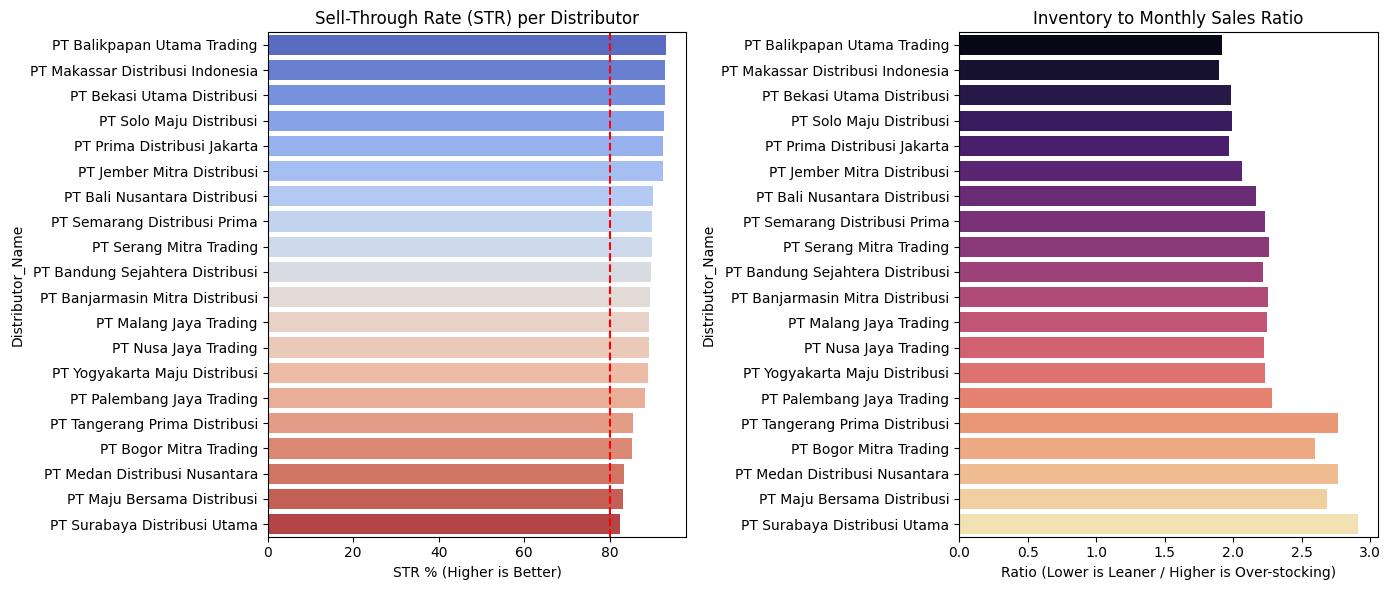

In [18]:
# 4. Visualizing Inventory Health vs Sales Efficiency
plt.figure(figsize=(14, 6))

# STR Analysis
plt.subplot(1, 2, 1)
sns.barplot(data=distributor_stats, x='STR_%', y='Distributor_Name', hue='Distributor_Name', palette='coolwarm', legend=False)
plt.axvline(80, color='red', linestyle='--', label='Benchmark 80%')
plt.title('Sell-Through Rate (STR) per Distributor')
plt.xlabel('STR % (Higher is Better)')

# Inventory Days Proxy (Inventory to Sales)
plt.subplot(1, 2, 2)
sns.barplot(data=distributor_stats, x='Inv_to_Sales_Ratio', y='Distributor_Name', hue='Distributor_Name', palette='magma', legend=False)
plt.title('Inventory to Monthly Sales Ratio')
plt.xlabel('Ratio (Lower is Leaner / Higher is Over-stocking)')

plt.tight_layout()
plt.show()

1. Sell-Through Rate (STR): Mayoritas distributor memiliki STR di atas benchmark 80%. PT Balikpapan Utama Trading (93.30%) dan PT Makassar Distribusi Indonesia (93.04%) memimpin sebagai distributor paling efisien dalam menyalurkan stok ke retail.
2. Inventory Health:
    * Lean Inventory: Distributor di Kalimantan dan Sulawesi menunjukkan rasio inventory-to-sales yang rendah (~3.0), artinya perputaran stok mereka sangat cepat dan sehat.
    * Over-stocking Risk: Beberapa distributor dengan STR yang lebih rendah (sekitar 83%) memiliki rasio inventori yang sama tingginya, yang bisa menandakan adanya penumpukan stok jika tren penjualan menurun.
3. Rekomendasi: Distributor dengan STR tinggi namun stok rendah perlu dipantau agar tidak terjadi out-of-stock, sementara yang memiliki STR rendah perlu dievaluasi efektivitas distribusi outlet-nya.

--- Product SKU Pareto Analysis ---


,Product_Name,Revenue,Profit,Units_Sold,Revenue_Share_%,Cumulative_Share_%,Classification,Profit_Margin_%
0,So Good Chicken Sausage 375g,"241,238,500","53,515,500","6,690",9.34%,9.34%,Core (Top 80%),22.18%
1,Anchor Cheddar Block 500g,"235,549,500","54,587,000","3,180",9.12%,18.45%,Core (Top 80%),23.17%
2,Bernardi Beef Sausage 500g,"166,316,000","35,084,500","3,188",6.44%,24.89%,Core (Top 80%),21.10%
3,Kraft Cheddar Cheese 165g,"160,443,500","40,695,500","5,109",6.21%,31.10%,Core (Top 80%),25.36%
4,So Good Chicken Nugget 500g,"150,592,000","22,627,000","3,113",5.83%,36.93%,Core (Top 80%),15.03%
5,Premium Whole Milk 1L,"147,556,000","17,989,500","5,865",5.71%,42.64%,Core (Top 80%),12.19%
6,Fiesta Crispy Nugget 400g,"143,694,500","21,053,000","3,487",5.56%,48.21%,Core (Top 80%),14.65%
7,Chocolate 1L,"129,779,000","16,352,000","6,775",5.02%,53.23%,Core (Top 80%),12.60%
8,Cimory Full Cream 1L,"122,057,500","15,415,500","5,722",4.72%,57.95%,Core (Top 80%),12.63%
9,Kimbo Beef Sausage 375g,"103,289,500","21,870,500","3,267",4.00%,61.95%,Core (Top 80%),21.17%


<Figure size 1400x700 with 0 Axes>

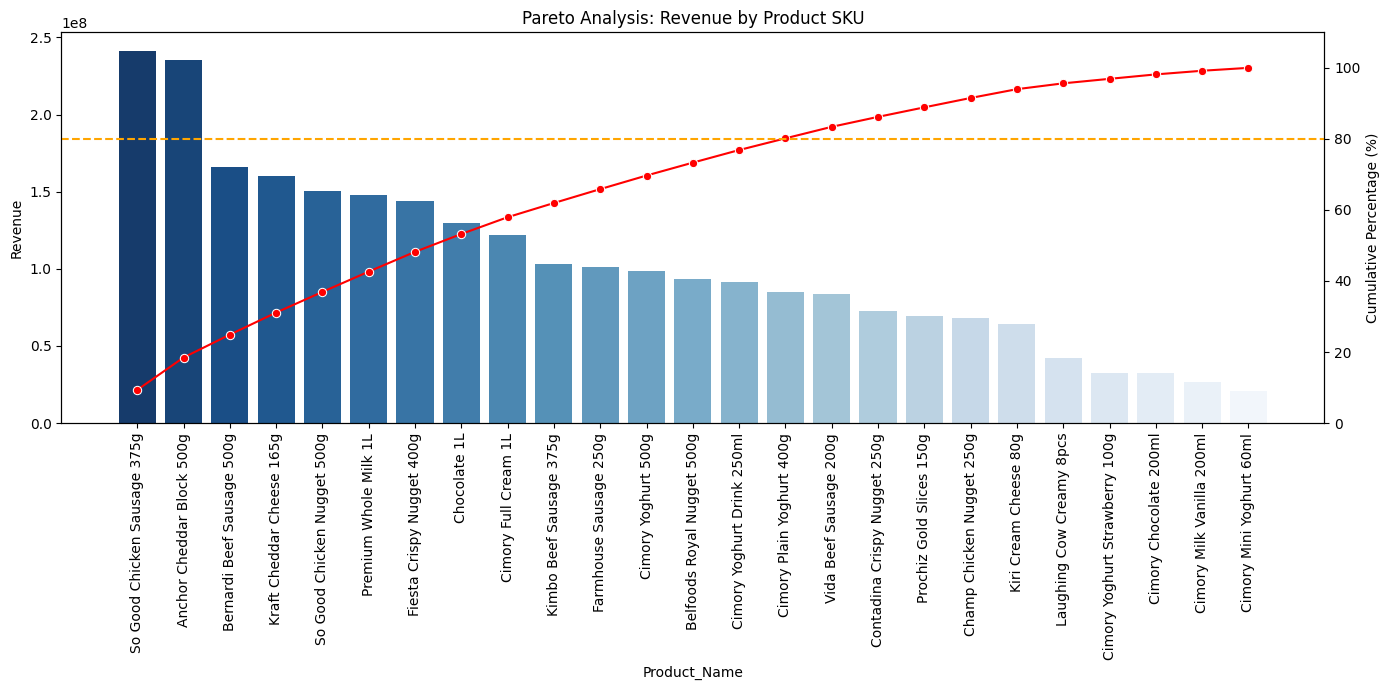

In [19]:
# Pareto 80/20 Analysis per Product (SKU)

# 1. Aggregate Revenue and Profit by Product
sku_analysis = df_fmcg_sales.groupby('Product_Name').agg({
    'Revenue': 'sum',
    'Profit': 'sum',
    'Units_Sold': 'sum'
}).sort_values(by='Revenue', ascending=False).reset_index()

# 2. Calculate Cumulative Percentages
total_revenue = sku_analysis['Revenue'].sum()
sku_analysis['Revenue_Share_%'] = (sku_analysis['Revenue'] / total_revenue) * 100
sku_analysis['Cumulative_Share_%'] = sku_analysis['Revenue_Share_%'].cumsum()

# 3. Classify Products (Pareto Classification)
sku_analysis['Classification'] = sku_analysis['Cumulative_Share_%'].apply(
    lambda x: 'Core (Top 80%)' if x <= 80 else 'Long-tail (Remaining 20%)'
)

# Calculate Profit Margin per SKU
sku_analysis['Profit_Margin_%'] = (sku_analysis['Profit'] / sku_analysis['Revenue']) * 100

print("--- Product SKU Pareto Analysis ---")
display(sku_analysis.style.format({
    'Revenue': '{:,.0f}',
    'Profit': '{:,.0f}',
    'Units_Sold': '{:,.0f}',
    'Revenue_Share_%': '{:.2f}%',
    'Cumulative_Share_%': '{:.2f}%',
    'Profit_Margin_%': '{:.2f}%'
}))

# 4. Visualization
plt.figure(figsize=(14, 7))

# Pareto Chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart for revenue - Fixed FutureWarning by assigning hue and legend=False
sns.barplot(data=sku_analysis, x='Product_Name', y='Revenue', ax=ax1, hue='Product_Name', palette='Blues_r', legend=False)
ax1.set_ylabel('Revenue')
plt.xticks(rotation=90)

# Line chart for cumulative percentage
ax2 = ax1.twinx()
sns.lineplot(data=sku_analysis, x='Product_Name', y='Cumulative_Share_%', ax=ax2, color='red', marker='o', sort=False)
ax2.axhline(80, color='orange', linestyle='--', label='80% Threshold')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)

plt.title('Pareto Analysis: Revenue by Product SKU')
plt.tight_layout()
plt.show()

Analisis Pareto 80/20 telah selesai. Berikut adalah temuan kuncinya:

1. Produk Core (Top 80%): Dari total 25 SKU, terdapat sekelompok kecil produk seperti So Good Chicken Sausage 375g dan Anchor Cheddar Block 500g yang mendominasi pendapatan. Produk-produk ini adalah 'mesin uang' Anda yang harus dijaga ketersediaan stoknya.
2. Long-tail (Remaining 20%): SKU di kategori ini memberikan kontribusi yang jauh lebih kecil secara akumulatif. Ini adalah area di mana Anda bisa mempertimbangkan rasionalisasi produk jika biaya logistik untuk SKU tersebut terlalu tinggi.
3. Profitability Check: Tabel menunjukkan bahwa beberapa produk dengan kontribusi pendapatan menengah sebenarnya memiliki Profit Margin % yang sangat sehat (di atas 20%), sehingga tetap memberikan nilai strategis bagi perusahaan.

--- Regional Gap vs Distributor Health ---


,Region,Achievement_%,Gap_Shortfall,STR_%,Inv_to_Sales_Ratio
0,Bali,85.18%,"-26,897,500",90.24%,2.16
5,Kalimantan,85.29%,"-32,151,500",91.43%,1.04
2,Central Java,85.29%,"-55,885,000",91.14%,1.06
1,Banten,86.16%,"-28,848,000",87.12%,1.28
7,Sumatera,86.17%,"-37,127,000",85.60%,1.27
9,Yogyakarta,86.22%,"-18,050,000",89.03%,2.23
6,Sulawesi,86.33%,"-22,139,000",93.04%,1.90
3,East Java,86.53%,"-48,696,500",86.73%,0.83
4,Jakarta,86.59%,"-82,252,500",87.39%,0.78
8,West Java,86.80%,"-62,429,000",88.81%,0.76



Korelasi Achievement_% vs STR_%: -0.485
Korelasi Achievement_% vs Inv_to_Sales_Ratio: -0.320


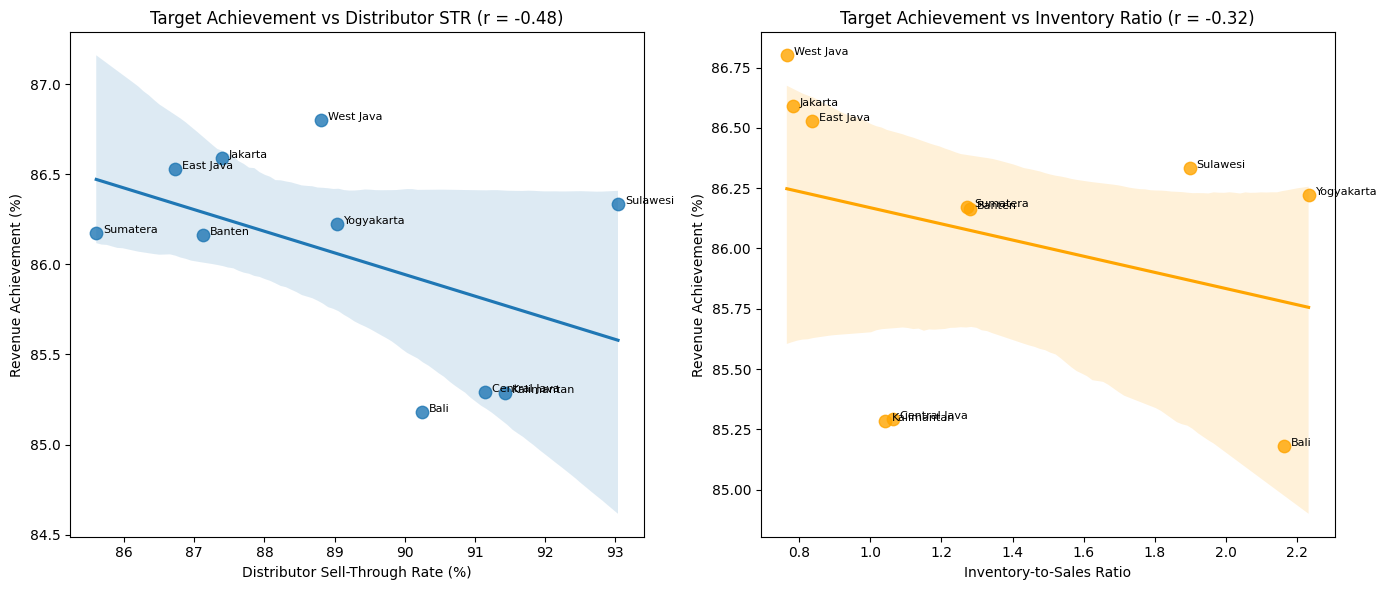


STR_% vs Achievement_%: korelasi sedang
Inv_to_Sales_Ratio vs Achievement_%: korelasi sedang


In [20]:
# Cross-Dataset Correlation: Regional Revenue Gap vs Distributor Health
# Menghubungkan 3 dataset untuk melihat apakah region dengan gap target terbesar
# juga punya masalah kesehatan distributor (STR rendah / inventory menumpuk)

# 1. Regional Revenue Gap (dari fmcg_sales vs sales_target)
regional_actual = df_fmcg_sales.groupby('Region')['Revenue'].sum().reset_index()
regional_target = df_sales_target.groupby('Region')['Target_Revenue'].sum().reset_index()

regional_gap = pd.merge(regional_actual, regional_target, on='Region')
regional_gap['Achievement_%'] = (regional_gap['Revenue'] / regional_gap['Target_Revenue']) * 100
regional_gap['Gap_Shortfall'] = regional_gap['Revenue'] - regional_gap['Target_Revenue']

# 2. Regional Distributor Health (dari distributor_performance, level region)
# Penting: gunakan sum/sum untuk STR (bukan rata-rata dari rasio per distributor)
# agar tidak bias oleh distributor kecil vs besar (menghindari Simpson's Paradox)
regional_distributor = df_distributor.groupby('Region').agg({
    'STD_Qty': 'sum',
    'STT_Qty': 'sum',
    'Ending_Inventory': 'mean'
}).reset_index()

regional_distributor['STR_%'] = (regional_distributor['STT_Qty'] / regional_distributor['STD_Qty']) * 100
regional_distributor['Inv_to_Sales_Ratio'] = (
    regional_distributor['Ending_Inventory'] / (regional_distributor['STT_Qty'] / 12)
)

# 3. Merge kedua sisi jadi satu tabel per Region
correlation_df = pd.merge(regional_gap, regional_distributor, on='Region')

print("--- Regional Gap vs Distributor Health ---")
display(correlation_df[[
    'Region', 'Achievement_%', 'Gap_Shortfall', 'STR_%', 'Inv_to_Sales_Ratio'
]].sort_values('Achievement_%').style.format({
    'Achievement_%': '{:.2f}%',
    'Gap_Shortfall': '{:+,.0f}',
    'STR_%': '{:.2f}%',
    'Inv_to_Sales_Ratio': '{:.2f}'
}))

# 4. Hitung koefisien korelasi (Pearson)
corr_achievement_str = correlation_df['Achievement_%'].corr(correlation_df['STR_%'])
corr_achievement_inv = correlation_df['Achievement_%'].corr(correlation_df['Inv_to_Sales_Ratio'])

print(f"\nKorelasi Achievement_% vs STR_%: {corr_achievement_str:.3f}")
print(f"Korelasi Achievement_% vs Inv_to_Sales_Ratio: {corr_achievement_inv:.3f}")

# 5. Visualisasi Scatter Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.regplot(data=correlation_df, x='STR_%', y='Achievement_%', scatter_kws={'s': 80})
for _, row in correlation_df.iterrows():
    plt.text(row['STR_%'] + 0.1, row['Achievement_%'], row['Region'], fontsize=8)
plt.title(f'Target Achievement vs Distributor STR (r = {corr_achievement_str:.2f})')
plt.xlabel('Distributor Sell-Through Rate (%)')
plt.ylabel('Revenue Achievement (%)')

plt.subplot(1, 2, 2)
sns.regplot(data=correlation_df, x='Inv_to_Sales_Ratio', y='Achievement_%', scatter_kws={'s': 80}, color='orange')
for _, row in correlation_df.iterrows():
    plt.text(row['Inv_to_Sales_Ratio'] + 0.02, row['Achievement_%'], row['Region'], fontsize=8)
plt.title(f'Target Achievement vs Inventory Ratio (r = {corr_achievement_inv:.2f})')
plt.xlabel('Inventory-to-Sales Ratio')
plt.ylabel('Revenue Achievement (%)')

plt.tight_layout()
plt.show()

# 6. Interpretasi otomatis kekuatan korelasi (panduan, bukan kesimpulan final)
def interpret_corr(r):
    r_abs = abs(r)
    if r_abs < 0.3:
        return "lemah / tidak ada korelasi berarti"
    elif r_abs < 0.6:
        return "korelasi sedang"
    else:
        return "korelasi kuat"

print(f"\nSTR_% vs Achievement_%: {interpret_corr(corr_achievement_str)}")
print(f"Inv_to_Sales_Ratio vs Achievement_%: {interpret_corr(corr_achievement_inv)}")

Berdasarkan hasil korelasi antara pencapaian target dan kesehatan distributor pada cell ini, berikut adalah beberapa insight utama yang dapat diambil:

1. Korelasi Sedang (r = -0.485): Terdapat hubungan terbalik yang moderat antara Sell-Through Rate (STR) distributor dan pencapaian target. Hal ini cukup unik karena biasanya STR tinggi berkorelasi dengan pencapaian yang baik. Ini mengindikasikan bahwa di beberapa wilayah, meskipun distributor sangat efisien menyalurkan barang (STR tinggi), target yang ditetapkan mungkin terlalu agresif sehingga tetap sulit tercapai.

2. Inventory-to-Sales Ratio (r = -0.320): Korelasi negatif yang lemah menunjukkan bahwa penumpukan stok (high ratio) memiliki sedikit pengaruh terhadap kegagalan pencapaian target secara regional. Artinya, masalah tidak tercapainya target lebih didominasi oleh faktor permintaan pasar (demand) atau penetapan angka target itu sendiri, bukan karena masalah logistik atau stok di level distributor.

3. Fokus Strategis: Perusahaan sebaiknya meninjau kembali metodologi penetapan target di wilayah dengan STR tinggi namun pencapaian rendah, agar target tetap realistis namun menantang.

# Executive Summary: FMCG Sales Performance 2024

## 1. Ringkasan Keseluruhan
Total Revenue 2024 tercatat **Rp 2,58 Miliar** dengan Profit **Rp 484,5 Juta** (margin keseluruhan **18,75%**). Pencapaian terhadap target nasional berada di **86,17%** dari total target Rp 2,998 Miliar — shortfall **Rp 414,5 Juta**. Tidak ada satu pun region yang mencapai 100% target.

## 2. Tren Penjualan
- MoM sangat fluktuatif: penurunan berturut-turut dari Agustus (-15,3%) hingga puncaknya Oktober (**-28,4%**), lalu rebound tajam di November (+66,1%) dan Desember (**+83,3%**).
- Kategori terbesar: Sausage (26,9%), Cheese (22,1%), Nugget (20,5%).

## 3. Regional Performance
- Jakarta (20,6%) dan West Java (15,9%) berkontribusi **36,5%** dari total revenue.
- Shortfall absolut terbesar: Jakarta **-Rp 82,25 Juta**, West Java **-Rp 62,43 Juta**.
- Achievement rate antar region seragam (85,2%–86,8%, rentang hanya 1,6pp) — mengindikasikan gap lebih ke soal baseline target daripada eksekusi regional.

## 4. Channel Performance
- Distributor mendominasi (55,4% revenue, AOV Rp 4,01 Juta), diikuti Modern Trade (25,9%) dan General Trade (18,7%).
- Margin ketiga channel **praktis setara** (18,69%–18,87%, selisih <0,2pp) — perbedaan revenue murni soal volume, bukan efisiensi biaya.

## 5. Distributor Health
- Seluruh 20 distributor STR di atas 80% (rata-rata 89,1%).
- **Pola musiman terkonfirmasi secara statistik**: rata-rata Inventory-to-Sales Ratio nasional 1,92, dengan 3 bulan melampaui ambang batas (mean + 1 std = 2,67) — **Januari (3,42), Oktober (2,71), November (2,69)**. Ini bukan anomali Oktober semata, melainkan pola berulang di awal dan akhir tahun.
- Region dengan penumpukan tertinggi di Oktober: **Bali (5,92), Central Java (4,01), Yogyakarta (3,87)**.
- **Tidak ditemukan korelasi kuat** antara kesehatan distributor dan pencapaian target (r = -0,48 untuk STR, r = -0,32 untuk Inventory Ratio) — dengan rentang achievement yang sangat sempit (1,6pp) di 10 region, gap target lebih mungkin didorong oleh baseline target atau demand pasar, bukan masalah distribusi.

## 6. Konsentrasi Produk (Pareto 80/20)
14 dari 25 SKU berkontribusi 80% revenue, didominasi *So Good Chicken Sausage 375g* (9,3%) dan *Anchor Cheddar Block 500g* (9,1%).

## 7. Rekomendasi Utama
1. Evaluasi ulang baseline target — pencapaian seragam ~85-87% di semua region mengindikasikan target mungkin ditetapkan terlalu agresif secara merata, bukan masalah eksekusi lokal.
2. Jaga ketersediaan stok 14 SKU Core.
3. Tinjau kebijakan safety stock menjelang Januari dan Oktober-November — pola penumpukan berulang di titik-titik ini, bukan kejadian tunggal.
4. Strategi channel sebaiknya fokus ke pertumbuhan volume, bukan argumen margin (karena margin antar channel setara).